In [27]:
import pandas as pd
import numpy as np
import math
from kneed import KneeLocator
from sklearn.cluster import DBSCAN
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [3]:
raw_data = pd.read_csv("tsne_scores.csv")

In [6]:
raw_data

,t-SNE-1,t-SNE-2
0,10.846841,-16.712580
1,24.794334,-16.775398
2,2.953309,13.379048
3,27.262146,-31.886690
4,-23.015728,64.468376
...,...,...
4401,-15.211057,-69.717155
4402,-9.403443,-62.847458
4403,-17.546083,-10.295582
4404,-8.512799,16.375420


In [11]:
X = raw_data.values
X

array([[ 10.846841 , -16.71258  ],
       [ 24.794334 , -16.775398 ],
       [  2.953309 ,  13.379048 ],
       ...,
       [-17.546083 , -10.295582 ],
       [ -8.512799 ,  16.37542  ],
       [-17.49305  ,  -2.6318119]], shape=(4406, 2))

In [12]:
minPts = 5

In [14]:
nbn = NearestNeighbors(n_neighbors=minPts)
nbn.fit(X)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [15]:
dist , indices = nbn.kneighbors(X)
k_dist = dist[:, minPts-1]


In [16]:
k_dist = np.sort(k_dist)

In [17]:
k_dist

array([ 0.18884391,  0.20602739,  0.28949417, ...,  5.85066405,
       10.48484593, 10.5479535 ], shape=(4406,))

In [18]:
x = np.arange(len(k_dist))

knee = KneeLocator(
    x,
    k_dist,
    curve="convex",
    direction="increasing"
)

eps = k_dist[knee.knee]

print(eps)

3.19398172110565


In [28]:
dbscan = DBSCAN(eps,min_samples=minPts)
labels = dbscan.fit_predict(X)

In [29]:
dbscan.labels_

array([0, 0, 1, ..., 1, 1, 1], shape=(4406,))

Text(0, 0.5, 't-sne2 feature')

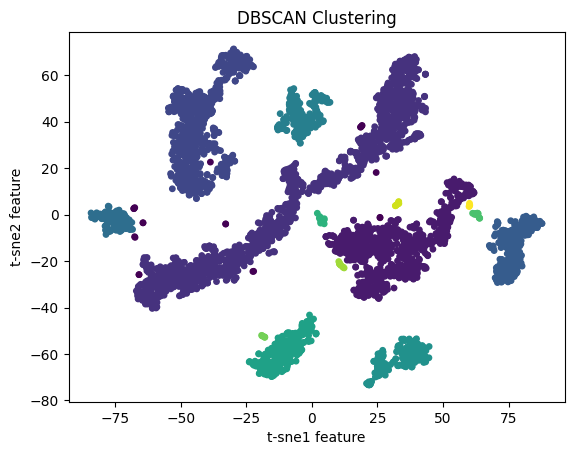

In [31]:
plt.scatter(X[:,0], X[:,1], c=labels, cmap="viridis", s=15)
plt.title("DBSCAN Clustering")
plt.xlabel("t-sne1 feature")
plt.ylabel("t-sne2 feature")
